In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dasandco/models/data.yaml
/kaggle/input/datasets/dasandco/models/final_classification_model.pth
/kaggle/input/datasets/dasandco/models/final_detection.pt
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train_meta.csv
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/cliniscan_classification_model.pth
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train.csv
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/cliniscan_detection_model (1).pt
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/b3f67ac077531f44dd06275af31edbd9.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/e94fde220360e4b769921e16059cc6af.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/d2993271d0a49d1d821db1174861629a.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/99732e844196448b90e50973d6ba5224.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/3c6f70f56258cad13d74e7f17da1c7c5.png
/kaggle/input/datasets/dasandco/cl

In [2]:
!pip install ultralytics

import torch
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from sklearn.metrics import accuracy_score, f1_score
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
train_csv = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train.csv"
meta_csv = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train_meta.csv"

df = pd.read_csv(train_csv)
meta = pd.read_csv(meta_csv)

print("Train rows:", len(df))
print("Meta rows:", len(meta))

Train rows: 67914
Meta rows: 15000


In [4]:
df = df[df["class_id"] != 14]

print("After removing No finding:", len(df))

After removing No finding: 36096


In [5]:
df = df.dropna(subset=["x_min","y_min","x_max","y_max"])

print("Valid annotations:", len(df))

Valid annotations: 36096


In [6]:
size_dict = {}

for _, row in meta.iterrows():
    size_dict[row["image_id"]] = (row["dim0"], row["dim1"])

In [7]:
base = "/kaggle/working/dataset"

img_dir = f"{base}/images/train"
lbl_dir = f"{base}/labels/train"

os.makedirs(img_dir, exist_ok=True)
os.makedirs(lbl_dir, exist_ok=True)

In [8]:
from tqdm import tqdm

for img_id, group in tqdm(df.groupby("image_id")):
    h, w = size_dict[img_id]

    label_path = os.path.join(lbl_dir, img_id + ".txt")

    with open(label_path, "w") as f:
        for _, row in group.iterrows():
            x_min = row["x_min"]
            y_min = row["y_min"]
            x_max = row["x_max"]
            y_max = row["y_max"]

            xc = ((x_min + x_max) / 2) / w
            yc = ((y_min + y_max) / 2) / h

            bw = (x_max - x_min) / w
            bh = (y_max - y_min) / h

            class_id = int(row["class_id"])

            f.write(f"{class_id} {xc} {yc} {bw} {bh}\n")

100%|██████████| 4394/4394 [00:02<00:00, 1625.83it/s]


In [9]:
src_img_dir = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train"

for img in tqdm(os.listdir(src_img_dir)):
    
    src = os.path.join(src_img_dir, img)
    dst = os.path.join(img_dir, img)

    if not os.path.exists(dst):
        os.system(f"cp {src} {dst}")

100%|██████████| 15001/15001 [04:12<00:00, 59.48it/s]


In [10]:
images = set([os.path.splitext(f)[0] for f in os.listdir(img_dir)])
labels = set([os.path.splitext(f)[0] for f in os.listdir(lbl_dir)])

missing = images - labels

for img in missing:
    open(os.path.join(lbl_dir, img + ".txt"), "w").close()

print("Empty labels created:", len(missing))

Empty labels created: 10607


In [11]:
print("Images:", len(os.listdir(img_dir)))
print("Labels:", len(os.listdir(lbl_dir)))

Images: 15001
Labels: 15001


In [12]:
data_yaml = """
train: /kaggle/working/dataset/images/train
val: /kaggle/working/dataset/images/train

nc: 14

names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcification
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung Opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumothorax
  13: Pulmonary fibrosis
"""

with open("/kaggle/working/data.yaml","w") as f:
    f.write(data_yaml)

In [13]:
#Define Paths
DET_MODEL_PATH = "/kaggle/input/datasets/dasandco/models/final_detection.pt"
CLS_MODEL_PATH = "/kaggle/input/datasets/dasandco/models/final_classification_model.pth"

# Load Detection Model

In [14]:
det_model = YOLO(DET_MODEL_PATH)

In [15]:
#Detection Evaluation
metrics = det_model.val()

print("===== DETECTION RESULTS =====")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,418,218 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3006.3±872.8 MB/s, size: 422.9 KB)
val: Scanning /kaggle/working/dataset/labels/train... 15000 images, 10606 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15000/15000 1.2Kit/s 12.2s
val: New cache created: /kaggle/working/dataset/labels/train.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 938/938 2.2it/s 7:11
                   all      15000      36096      0.493      0.425      0.436      0.232
    Aortic enlargement       3067       7162      0.658      0.621      0.682      0.436
           Atelectasis        186        279      0.376      0.348      0.329      0.149
         Calcification        452        960      0.375       0.44      0.366       0.18
          Cardiomegaly       2300       5427      0.7

# Load Classification Model

In [16]:
import torch
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 14)

model.load_state_dict(torch.load("/kaggle/input/datasets/dasandco/models/final_classification_model.pth", map_location=device))
model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata"

df = pd.read_csv(f"{DATA_PATH}/train.csv")

In [18]:
df["image_path"] = DATA_PATH + "/train/" + df["image_id"] + ".png"

In [19]:
df["label"] = df["class_id"] - 1

# Remove invalid labels
df = df[df["label"] >= 0]
df = df[df["label"] < 14]

print("Label range:", df["label"].min(), df["label"].max())

Label range: 0 13


In [20]:
import cv2
from torch.utils.data import Dataset

class XRayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = int(row["label"])

        image = cv2.imread(img_path)

        if image is None:
            raise ValueError(f"Image not found: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        return image, label

In [21]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [22]:
from torch.utils.data import DataLoader

dataset = XRayDataset(df, transform=transform)

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

In [23]:
images, labels = next(iter(loader))
print(images.shape, labels.shape)

torch.Size([16, 3, 224, 224]) torch.Size([16])


# Classification Evaluation

In [24]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()

all_preds = []
all_labels = []

MAX_BATCHES = 100   

with torch.no_grad():
    for i, (images, labels) in enumerate(loader):
        if i >= MAX_BATCHES:  
            break

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

print("==== FAST EVALUATION ====")
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average='macro'))

==== FAST EVALUATION ====
Accuracy: 0.071875
F1 Score: 0.01674051883750442


In [25]:
import json

results_dict = {
    "Classification": {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "F1": f1_score(all_labels, all_preds, average='macro')
    }
}

with open("/kaggle/working/classification_results.json", "w") as f:
    json.dump(results_dict, f)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=2b7a73bae05a08b2600dbd1efafb84d92367de7ae9e1d74a8482be6bc475ec5e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam

image 1/1 /kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/bb3cb6e89c003ad4be9c6141b1d66723.png: 1024x1024 1 Nodule/Mass, 32.3ms
Speed: 6.1ms preprocess, 32.3ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 1024)


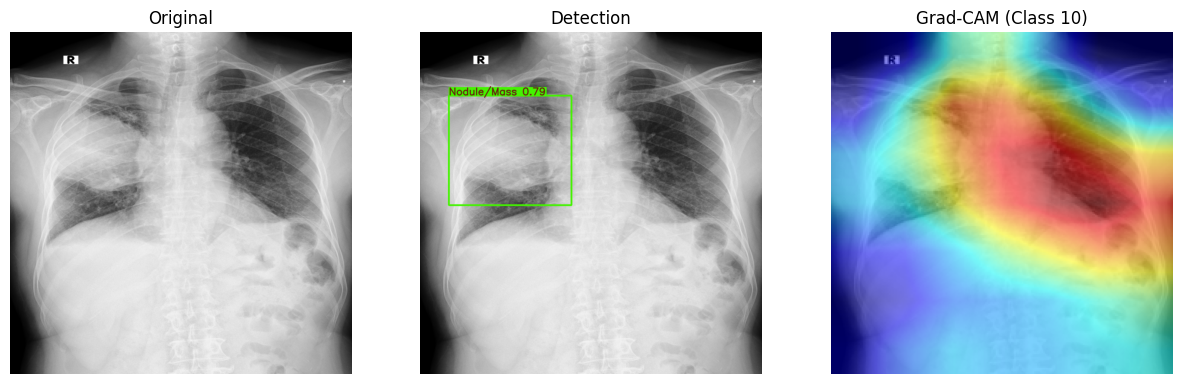


image 1/1 /kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/77479e09e740cfce8962e9e55963330e.png: 1024x1024 (no detections), 32.4ms
Speed: 4.4ms preprocess, 32.4ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)


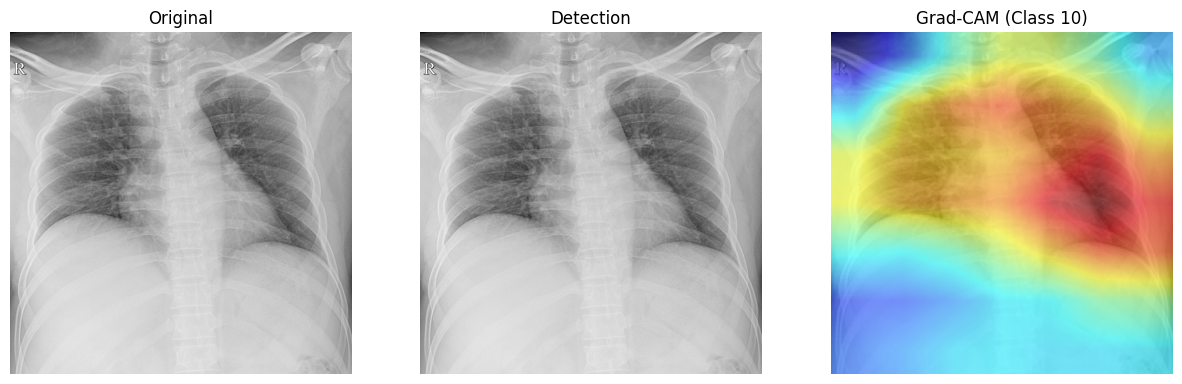


image 1/1 /kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/230ced5935d8f83f1b9f52bb95059263.png: 1024x1024 (no detections), 32.3ms
Speed: 4.6ms preprocess, 32.3ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)


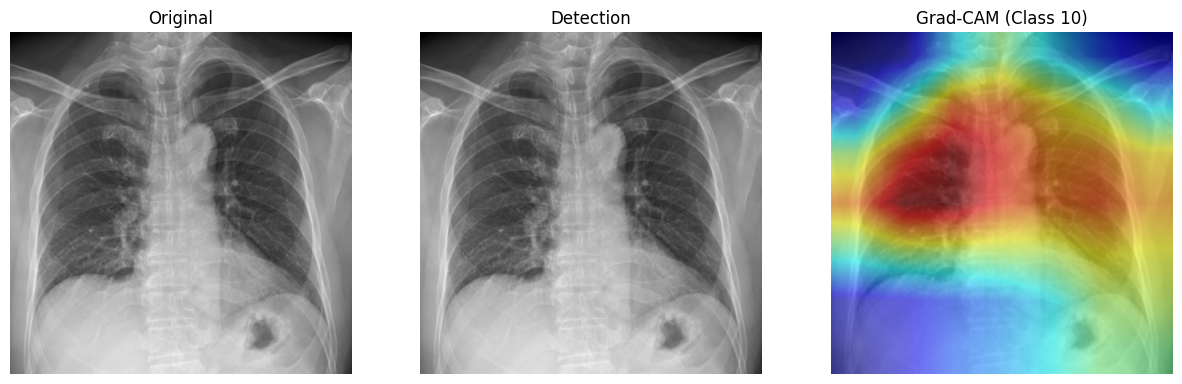


image 1/1 /kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/ea93703162b05a5c8acf2e18c2f69acf.png: 1024x1024 (no detections), 32.4ms
Speed: 5.2ms preprocess, 32.4ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)


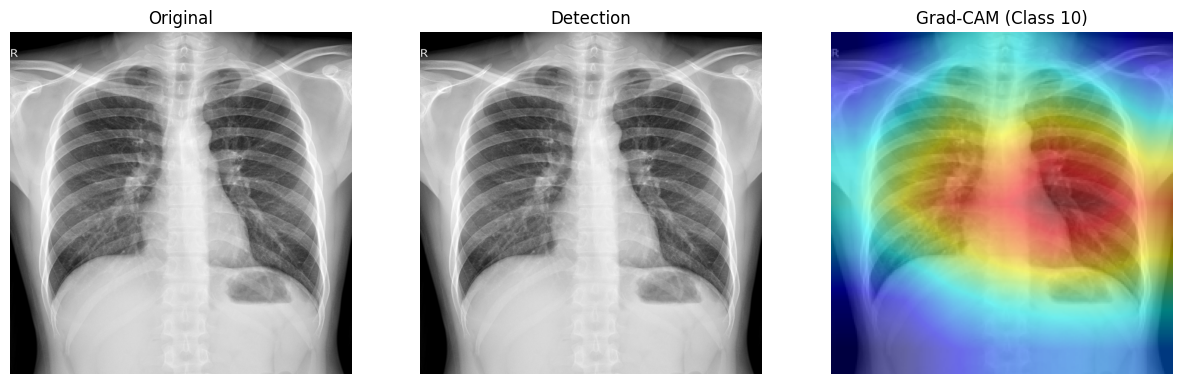


image 1/1 /kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/1ddd49f2867bac4430aaad6d35445a61.png: 1024x1024 (no detections), 32.4ms
Speed: 5.1ms preprocess, 32.4ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)


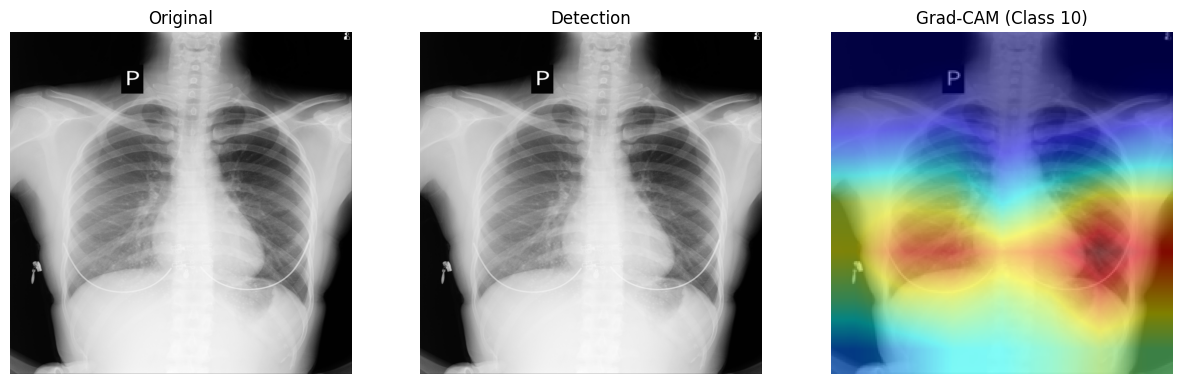

In [26]:
import os
import random
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import torchvision.transforms as transforms

# Grad-CAM
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# =========================
# LOAD MODELS
# =========================
det_model = YOLO("/kaggle/input/datasets/dasandco/models/final_detection.pt")

model.load_state_dict(torch.load("/kaggle/input/datasets/dasandco/models/final_classification_model.pth"))
model.eval()
model.to(device)

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# =========================
# TEST IMAGES
# =========================
test_dir = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test"
image_list = os.listdir(test_dir)

# pick 5 random images
random_images = random.sample(image_list, 5)

# =========================
# GRAD-CAM SETUP
# =========================
target_layer = model.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

# =========================
# LOOP THROUGH IMAGES
# =========================
for img_name in random_images:
    
    img_path = os.path.join(test_dir, img_name)

    # -------- Original Image --------
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # -------- Detection --------
    results = det_model(img_path)
    for r in results:
        det_img = r.plot()

    # -------- Classification --------
    image_pil = Image.open(img_path).convert("RGB")
    input_tensor = transform(image_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)

    # -------- Grad-CAM --------
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    img_np = np.array(image_pil.resize((224,224))) / 255.0
    cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # =========================
    # PLOT EVERYTHING
    # =========================
    fig, axs = plt.subplots(1,3, figsize=(15,5))

    axs[0].imshow(img_rgb)
    axs[0].set_title("Original")
    axs[0].axis("off")

    axs[1].imshow(det_img)
    axs[1].set_title("Detection")
    axs[1].axis("off")

    axs[2].imshow(cam_img)
    axs[2].set_title(f"Grad-CAM (Class {pred.item()})")
    axs[2].axis("off")

    plt.show()